# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# PCA utilities 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler



# Import the basal Ganglia model 
%load_ext autoreload
%autoreload 2
from bg_model import BasalGanglia
%load_ext autoreload
%autoreload 2
from utility import Utility

# Reload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Bundle Creation & Scaling

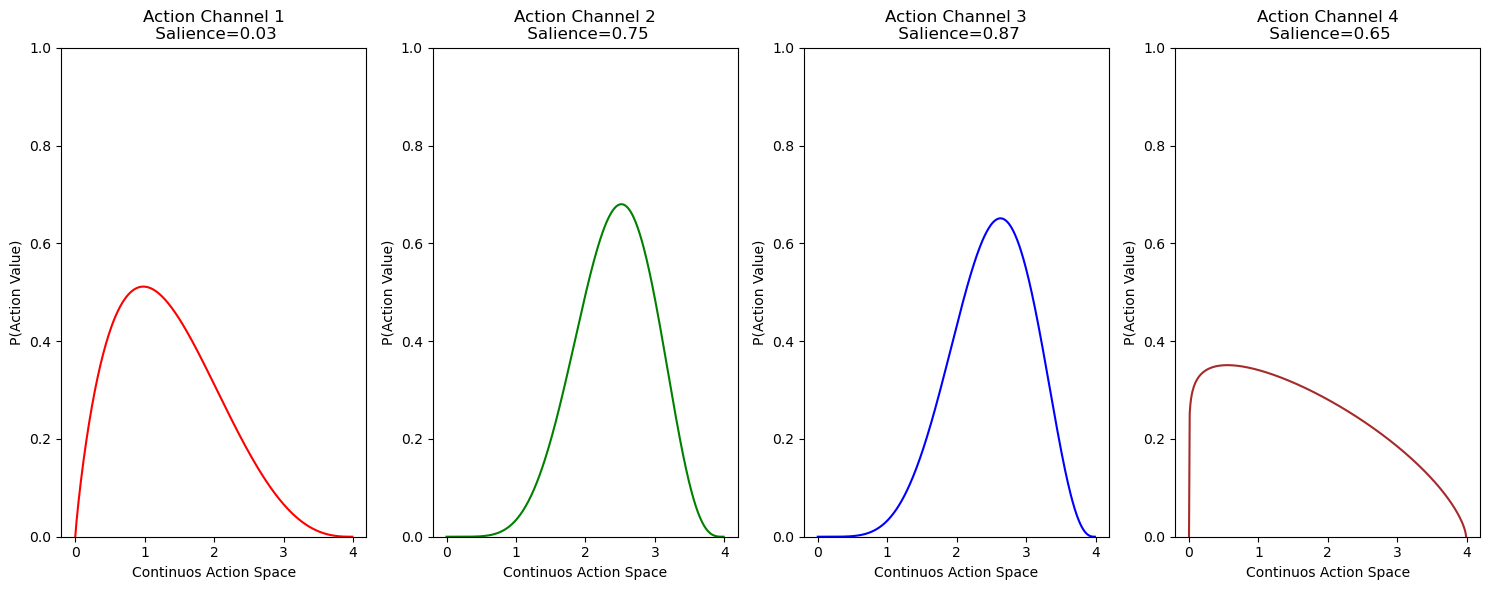

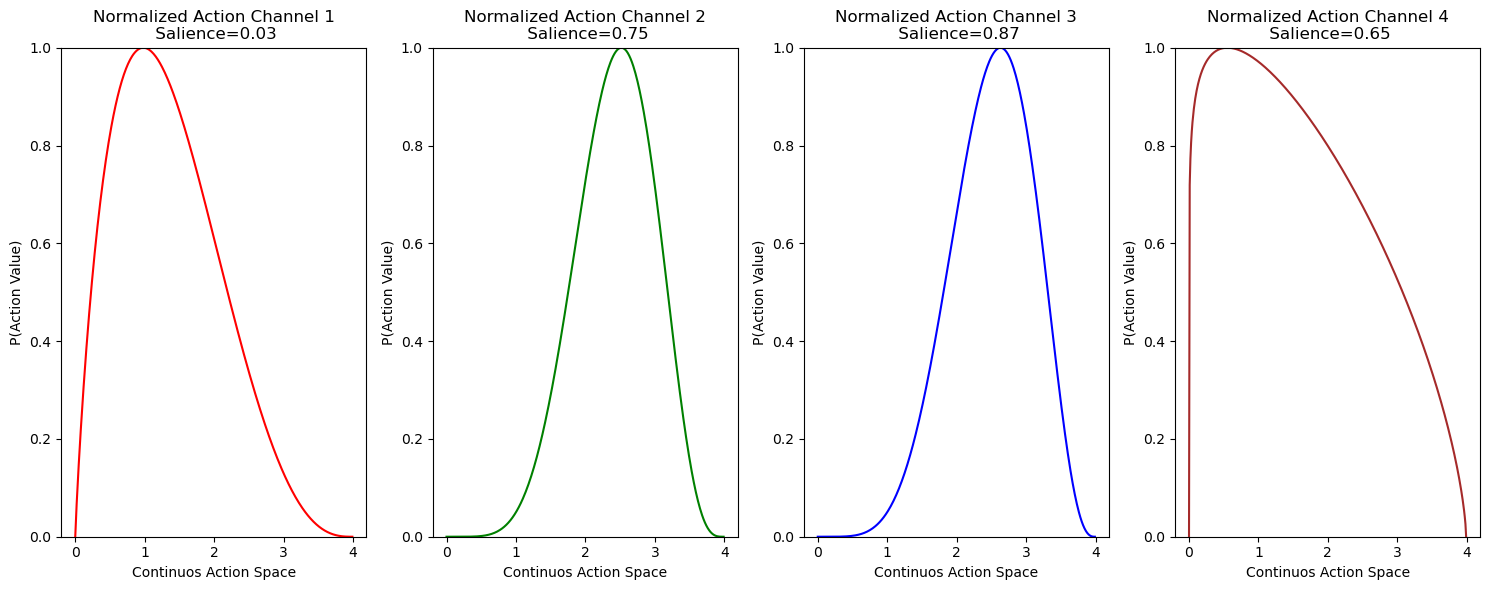

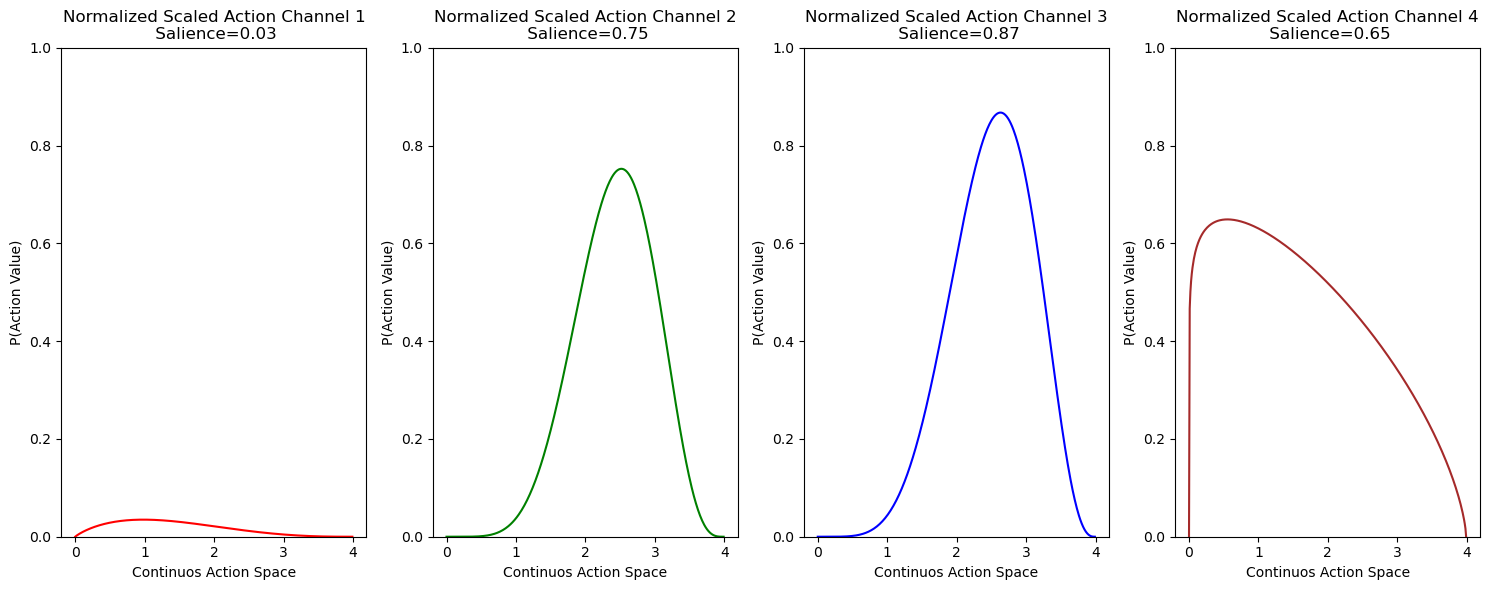

In [2]:
# Domain:  [0, 4]
domain = np.arange(0, 4, 0.01).reshape(-1, 1) # Shape: (400, 1)
# from sspspace.encoders import RandomSSPSpace  
from sspspace.sspspace.encoders import RandomSSPSpace
# SSP encoder
ssp_encoder = RandomSSPSpace(
    domain_dim = 1, # scalar action values
    ssp_dim = 512, # high dimensional SSPs
    rng=np.random.RandomState(), 
    length_scale=0.5
)

# Convert scalar action values into high dimensional SSPs
domain_phis = ssp_encoder.encode(domain) # Shape: (400, 512)

# Place cell encoders for Nengo ensembles
low = 0
high = 4
width = high - low
places_ = np.arange(low, high, width/(domain.shape[0]))
encoders = np.asarray(ssp_encoder.encode(places_.reshape(-1, 1))).squeeze()

# Create distributions 
n_actions = 4 # Number of action channels in the BG model 
seed = 20889604
rng = np.random.RandomState(seed)
# Randomly sample a's and b's to create distributions 
a_s = np.random.uniform(low = 1, high = 10, size = n_actions)
b_s = np.random.uniform(low = 1, high = 10, size = n_actions)

beta_distributions = []

for i in range(n_actions):
    # Beta PDF over domain 
    beta_pdfs = beta.pdf(domain, a_s[i], b_s[i], scale=domain[-1]) # Shape: (400, 1)
    beta_distributions.append(beta_pdfs)

# Scale by salience
salience = np.random.uniform(low = 0, high = 1, size = n_actions)

# Plot the Distributions
colors = ['red', 'green', 'blue', 'brown']
fig, axs = plt.subplots(1, n_actions, figsize=(15, 6))
for i in range(n_actions):
    axs[i].plot(domain, beta_distributions[i], color=colors[i])
    axs[i].set_title(f'Action Channel {i + 1}\n Salience={salience[i]:.2f}', fontsize=12)
    axs[i].set_xlabel("Continuos Action Space")
    axs[i].set_ylabel("P(Action Value)")
    axs[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Plot the normalized version of the distributions
normalized_distributions = Utility.to_normalize(beta_distributions)
fig, axs = plt.subplots(1, n_actions, figsize=(15, 6))
for i in range(n_actions):
    axs[i].plot(domain, normalized_distributions[i], color=colors[i])
    axs[i].set_title(f'Normalized Action Channel {i + 1}\n Salience={salience[i]:.2f}', fontsize=12)
    axs[i].set_xlabel("Continuos Action Space")
    axs[i].set_ylabel("P(Action Value)")
    axs[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Plot the scaled (by salience) version of the distributions
scaled_norm_dist = Utility.to_scale(salience, Utility.to_normalize(beta_distributions))
fig, axs = plt.subplots(1, n_actions, figsize=(15, 6))
for i in range(n_actions):
    axs[i].plot(domain, scaled_norm_dist[i], color=colors[i])
    axs[i].set_title(f'Normalized Scaled Action Channel {i + 1}\n Salience={salience[i]:.2f}', fontsize=12)
    axs[i].set_xlabel("Continuos Action Space")
    axs[i].set_ylabel("P(Action Value)")
    axs[i].set_ylim(0, 1)
plt.tight_layout()
# plt.savefig('./figures/bgmodel/bg_distribution.png')
plt.show()


## DNF Parameters

In [3]:
dnf_params = {'h'       : -3.009416816439706,
            'global_inh'      : 8.641108231311897,
            'tau'             : 0.04706404390267922,
            'exc'             : 9.421285790349613,
            'inh'             : 1.4841093480380807,
            'exc_w'           : 8.534993467227224,
            'inh_w'           : 4.748154014869723,
            'dt'              : 0.001, 
            'c_noise'         : 1.0,
            'shape'           : [(n_actions, 400)], 
            'beta'            : 4,
    }

# Build the Basal Ganglia Model

In [4]:
# 3). DNF/BG Parameters
d1_weight = 1.0
d2_weight = 1.0
dopamine_level = 0.2

input_bundle = Utility.to_bundle(Utility.to_scale(salience, Utility.to_normalize(beta_distributions)), domain_phis=domain_phis)
# BG Model
bg_model = BasalGanglia(n_actions=n_actions, dnf_parameters=dnf_params, encoders=encoders)
# Add neuron-level probes 
# 1. D1 & D2 DNFs
bg_model.add_probe('d1_dnf', what='neurons', name='d1_neurons')
bg_model.add_probe('d2_dnf', what='neurons', name='d2_neurons')
# 2. Subcortical nuclei 
bg_model.add_probe('stn', what='neurons', name='stn_neurons')
bg_model.add_probe('gpe', what='neurons', name='gpe_neurons')
bg_model.add_probe('gpi', what='neurons', name='gpi_neurons')

# Simulate the BG model
data = bg_model.simulate(input_bundles=input_bundle, dopamine_level=dopamine_level, presentation_time=1.5, duration=1.5)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/nengo/neurons.py:489: RuntimeWarning: overflow encountered in exp
  output[...] = (1.0 / self.tau_ref) / (1 + np.exp(-J))


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

## Plotting

### Input to Basal Ganglia Model

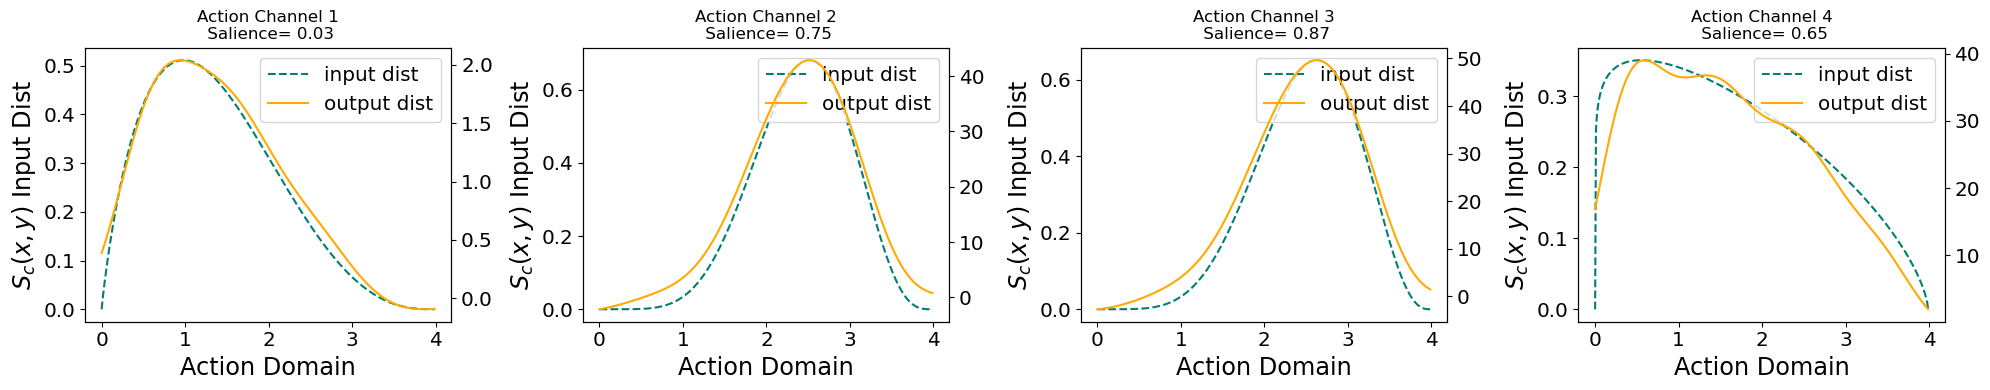

In [5]:
inp_dec = []
for i in range(n_actions):
    seg_in = data['bundle_ins'][i][-1] # Shape: (512, 1)
    inp_dec_uni = np.einsum('d,nd->n', seg_in, domain_phis)
    inp_dec.append(inp_dec_uni)

#7). Plot N channel side by side, each with twin y axes
fig, axes = plt.subplots(
    1, n_actions,
    figsize=(5 * n_actions, 4),
    sharex=True
)

# If you only have one action, axes will not be a list
if n_actions == 1:
    axes = [axes]


for i, ax in enumerate(axes):
    # primary y-axis: input distribution
    ax.plot(domain.squeeze(), beta_distributions[i],
            ls='--', color="#007e74",
            label="input dist")
    ax.set_xlabel("Action Domain", fontsize="xx-large")
    ax.set_ylabel("$S_c(x,y)$ Input Dist", fontsize="xx-large")
    ax.tick_params(axis='x', labelsize='x-large')
    ax.tick_params(axis='y', labelsize='x-large')

    # secondary y-axis: output distribution
    ax2 = ax.twinx()
    ax2.plot(domain.squeeze(), inp_dec[i],
             ls='-', color="#ffaa00",
             label="output dist")
    ax2.tick_params(axis='y', labelsize='x-large')

    # combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2,
              loc='upper right', fontsize='x-large')
    ax.set_title(f'Action Channel {i + 1}\n Salience={salience[i]: .2f}')

plt.tight_layout()
# plt.savefig("./figures/bgmodel/bg_input.png")
plt.show()



### D1 & D2 DNF 

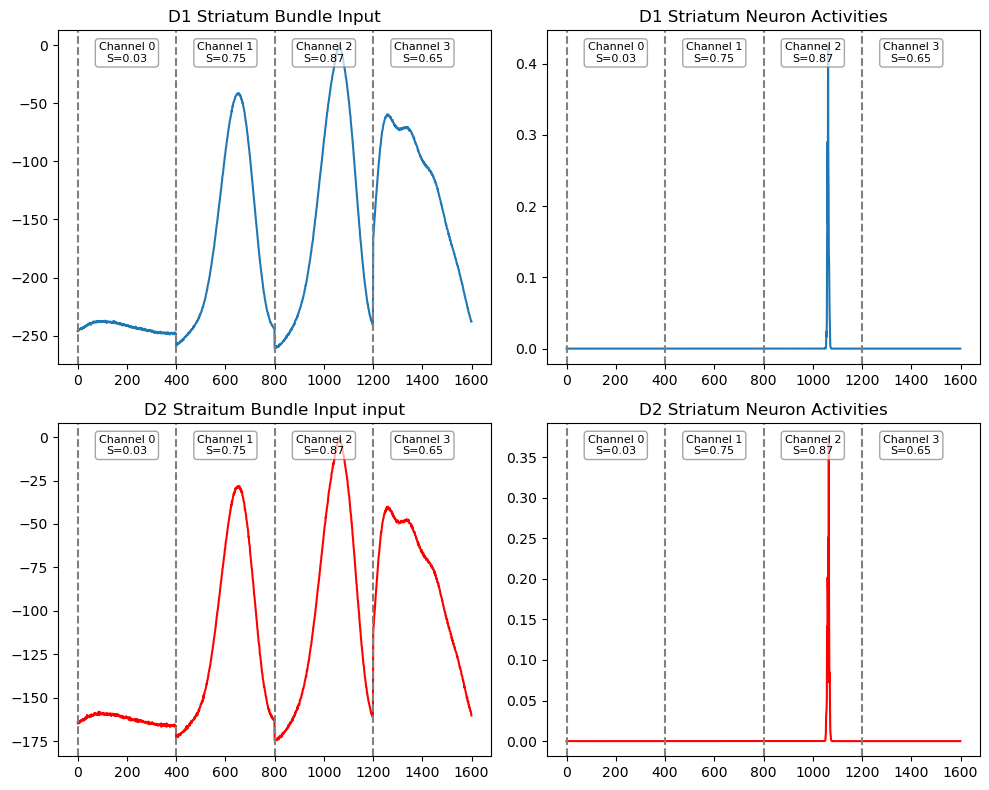

In [6]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8),)
# D1
# D1 Input to DNF
axes[0,0].plot(data['d1_input'][-1])
axes[0,0].set_title("D1 Striatum Bundle Input")
# D1 Neuron Activities
axes[0,1].plot(data['d1_neuron'][-1])
axes[0,1].set_title("D1 Striatum Neuron Activities" )

# D2
# D2 Input to DNF
axes[1,0].plot(data['d2_input'][-1], color='red')
axes[1,0].set_title("D2 Straitum Bundle Input input")
# D2 Neuron activities 
axes[1,1].plot(data['d2_neuron'][-1], color ='red')
axes[1,1].set_title("D2 Striatum Neuron Activities" )

# --- Add separation lines and labels ---
for ax in axes.ravel():
    ylim = ax.get_ylim()
    y_label = ylim[0] + (ylim[1] - ylim[0]) * 0.90  # 5% above baseline (consistent placement)

    for i in range(n_actions):
        xpos = i * domain.shape[0]
        ax.axvline(x=xpos, linestyle='--', color='grey')

        # Compute center of the current channel
        if i < n_actions - 1:
            xmid = xpos + domain.shape[0] / 2
        else:
            xmax = len(data['d1_input'][-1])
            xmid = xpos + (xmax - xpos) / 2

        # Add consistent text labels
        ax.text(
            xmid, y_label,
            f"Channel {i}\nS={salience[i]:.2f}",
            ha="center", va="bottom", fontsize=8, color="black",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.7)
        )

plt.tight_layout()
# plt.savefig("./figures/bgmodel/bg_dnf.png")
plt.show()


### Input Vs. Output Distribution

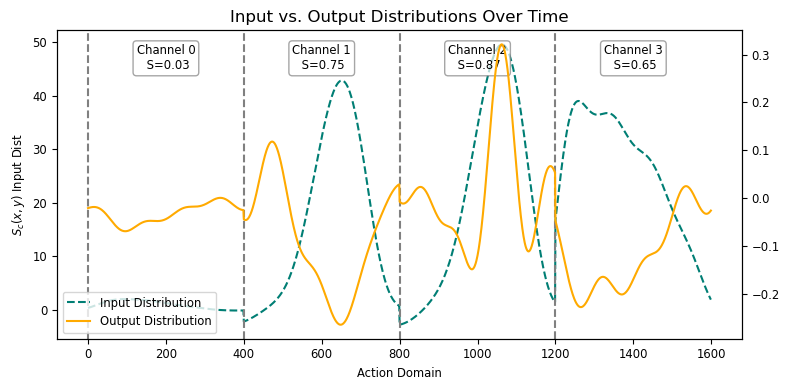

In [7]:
# Convert 512D SSP to Bundle 
output = []
for i_out in range(n_actions):
    seg = data['bundle_out'][-1][i_out * 512: (i_out + 1) * 512]
    seg_b = np.einsum('n,cn->c', seg, domain_phis)
    output.append(seg_b)

# hstack 
output_data = np.hstack(output)
input_data = np.hstack(inp_dec)

fig, ax = plt.subplots(figsize=(8, 4))
# Primary y-axis: input distribution
ax.plot(input_data,
        ls='--', color="#007e74",
        label="Input Distribution")
ax.set_xlabel("Action Domain", fontsize="small")
ax.set_ylabel('$S_c(x,y)$ Input Dist',
              fontsize='small', rotation=90,
              labelpad=10, va='center')
ax.tick_params(axis='x', labelsize='small')
ax.tick_params(axis='y', labelsize='small')

# Secondary y-axis: output distribution
ax2 = ax.twinx()
ax2.plot(output_data,
            ls='-', color="#ffaa00",
            label="Output Distribution")
ax2.tick_params(axis='y', labelsize='small')

# Combined legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2,
            loc='lower left', fontsize='small')
ax.set_title(f'Input vs. Output Distributions Over Time', fontsize="large")
 
# Channel separation lines + labels
for n in range(n_actions):
    xpos = n * domain.shape[0]
    ax.axvline(xpos, linestyle='--', color='gray')

    # Compute midpoint for text label
    if n < n_actions - 1:
        next_xpos = (n + 1) * domain.shape[0]
        x_text = (xpos + next_xpos) / 2
    else:
        x_text = xpos + domain.shape[0] / 2

    # Place text inside the plot region (on primary y-axis scale)
    y_text = ax.get_ylim()[1] * 0.95
    ax.text(
        x_text, y_text,
        f"Channel {n}\n S={salience[n]:.2f}",
        ha='center', va='top',
        fontsize='small',
        bbox=dict(boxstyle="round,pad=0.3",
                    fc="white", ec="gray", alpha=0.7)
    )

plt.tight_layout()
# plt.savefig("./figures/bgmodel/bg_output.png")
plt.show()


# PCA Analysis 
PCA + Contrastive PCA Analysis on Neuron Activities 
- GPe
- DNF D1 & D2
- GPi
- STN

In [ ]:
# ---- PCA Helper functions ----- #
def run_pca(X, n_components=10, zscore=True, random_state=0):
    '''
    X: np.ndarray of shape (T, N) = time x neurons
    n_components: how many PCs to keep 
    zscore: if True, z-score each neuron so large-firing units don't dominate
    Returns: (pca, scores) where scores is (T, n_components)
    '''
    # Replace any NaNs, center/scale, then fit PCA
    X = np.nan_to_num(X, copy=True)
    scaler = StandardScaler(with_mean=True, with_std=zscore)
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=n_components, svd_solver="full", random_state=random_state)
    scores = pca.fit_transform(X_scaled)
    return X, X_scaled, pca, scores

# ---- Helper: collet multi-action probes by name prefix -----#
def collect_by_prefix(custom_probe_dict, prefix):
    '''
    Gathers all custom probes whose keys start with `prefix`.
    Each value is expected to be (T, N_pop) for one action channel.
    Concatenates along the neuron axis --> (T, sum_over_actions N_pop).
    '''
    mats = [v for k, v in custom_probe_dict.items() if k.startswith(prefix)]
    if not mats:
        raise KeyError(f"No custom probes found with prefix '{prefix}'. "
                       f"Available: {list(custom_probe_dict.keys())[:5]} ...")
    return np.concatenate(mats, axis=1) if len(mats) > 1 else mats[0]

In [ ]:


# ============================
# PCA of D1 / D2 neuron activity
# ============================


# ----- INPUTS ---------------------------------------------------------------
# Replace these with your actual arrays, e.g.:
X_d1 = data['d1_neuron']    # shape (1500, 1600)
X_d2 = data['d2_neuron']    # shape (1500, 1600)


# Known sampling: one row per 0.01 s
dt = 0.01
t = np.arange(X_d1.shape[0]) * dt  # time vector (s)

# ----- Helper: fit PCA and return components & scores -----------------------
def fit_pca_time_by_neuron(X, n_components=10, zscore=True, random_state=0):
    """
    X: (T, N) time x neurons
    n_components: number of PCs to keep
    zscore: if True, z-score each neuron across time
    Returns:
        scaler: StandardScaler used for centering/scaling
        pca: fitted PCA object
        scores: (T, n_components) time series in PC space
    """
    # Replace NaNs if any (defensive)
    X = np.nan_to_num(X, copy=True)

    # Center (and optionally scale) features = neurons
    scaler = StandardScaler(with_mean=True, with_std=zscore)
    Xc = scaler.fit_transform(X)  # still (T, N)

    # PCA over neurons (features) using time as observations
    pca = PCA(n_components=n_components, svd_solver="full", random_state=random_state)
    scores = pca.fit_transform(Xc)  # (T, n_components)
    return scaler, pca, scores

# ----- Run PCA for D1 and D2 -----------------------------------------------
n_components = 3
scaler_d1, pca_d1, Z_d1 = fit_pca_time_by_neuron(X_d1, n_components=n_components, zscore=True)
scaler_d2, pca_d2, Z_d2 = fit_pca_time_by_neuron(X_d2, n_components=n_components, zscore=True)

# ----- Project the LAST time step into each PCA space -----------------------
# (We transform the last row using the SAME scaler + PCA learned on the full time series.)
last_idx = -1

X_d1_last = X_d1[-1, :]                 # shape (1, N)
print(X_d1_last.shape)
X_d1_last_c = scaler_d1.transform(X_d1_last)             # center/scale using training scaler
last_scores_d1 = pca_d1.transform(X_d1_last_c)[0]        # shape (n_components,)

X_d2_last = X_d2[last_idx:last_idx+1, :]
X_d2_last_c = scaler_d2.transform(X_d2_last)
last_scores_d2 = pca_d2.transform(X_d2_last_c)[0]

print("D1 last-step PC scores (first 5):", np.round(last_scores_d1[:5], 3))
print("D2 last-step PC scores (first 5):", np.round(last_scores_d2[:5], 3))

# ====== PLOTTING ============================================================
plt.rcParams.update({"figure.figsize": (12, 10)})

# ---- (A) Explained variance profiles ---------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

# D1
evr_d1 = pca_d1.explained_variance_ratio_
ax[0].bar(np.arange(1, n_components+1), evr_d1, alpha=0.8)
ax[0].plot(np.arange(1, n_components+1), np.cumsum(evr_d1), marker='o')
ax[0].set_title("D1 PCA: variance explained")
ax[0].set_xlabel("Principal component")
ax[0].set_ylabel("Explained variance ratio")
ax[0].legend(["Cumulative", "Per-PC"], loc="upper right")

# D2
evr_d2 = pca_d2.explained_variance_ratio_
ax[1].bar(np.arange(1, n_components+1), evr_d2, alpha=0.8)
ax[1].plot(np.arange(1, n_components+1), np.cumsum(evr_d2), marker='o')
ax[1].set_title("D2 PCA: variance explained")
ax[1].set_xlabel("Principal component")
ax[1].set_ylabel("Explained variance ratio")
ax[1].legend(["Cumulative", "Per-PC"], loc="upper right")
plt.show()

# ---- (B) Low-D trajectories (PC1 vs PC2), colored by time ------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# D1 trajectory
sc1 = ax[0].scatter(Z_d1[:, 0], Z_d1[:, 1], c=t, s=10)
ax[0].plot(Z_d1[:, 0], Z_d1[:, 1], lw=0.7, alpha=0.6)
ax[0].scatter(Z_d1[last_idx, 0], Z_d1[last_idx, 1], s=80, marker='X', edgecolor='k', zorder=3)
ax[0].set_title("D1: PC1 vs PC2 (● time-colored, ✖ last step)")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
cbar1 = plt.colorbar(sc1, ax=ax[0])
cbar1.set_label("Time (s)")

# D2 trajectory
sc2 = ax[1].scatter(Z_d2[:, 0], Z_d2[:, 1], c=t, s=10)
ax[1].plot(Z_d2[:, 0], Z_d2[:, 1], lw=0.7, alpha=0.6)
ax[1].scatter(Z_d2[last_idx, 0], Z_d2[last_idx, 1], s=80, marker='X', edgecolor='k', zorder=3)
ax[1].set_title("D2: PC1 vs PC2 (● time-colored, ✖ last step)")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
cbar2 = plt.colorbar(sc2, ax=ax[1])
cbar2.set_label("Time (s)")
plt.show()

# ---- (C) PC1 and PC2 time courses with last-step marker --------------------
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)

# D1 time courses
ax[0].plot(t, Z_d1[:, 0], label="PC1")
ax[0].plot(t, Z_d1[:, 1], label="PC2")
ax[0].axvline(t[last_idx], ls='--', color='k', alpha=0.5)
ax[0].scatter(t[last_idx], Z_d1[last_idx, 0], color=ax[0].lines[0].get_color())
ax[0].scatter(t[last_idx], Z_d1[last_idx, 1], color=ax[0].lines[1].get_color())
ax[0].set_title("D1 PCs over time (last step marked)")
ax[0].set_ylabel("PC score")
ax[0].legend(loc="upper right")

# D2 time courses
ax[1].plot(t, Z_d2[:, 0], label="PC1")
ax[1].plot(t, Z_d2[:, 1], label="PC2")
ax[1].axvline(t[last_idx], ls='--', color='k', alpha=0.5)
ax[1].scatter(t[last_idx], Z_d2[last_idx, 0], color=ax[1].lines[0].get_color())
ax[1].scatter(t[last_idx], Z_d2[last_idx, 1], color=ax[1].lines[1].get_color())
ax[1].set_title("D2 PCs over time (last step marked)")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("PC score")
ax[1].legend(loc="upper right")
plt.show()



(0, 1600)


ValueError: Found array with 0 sample(s) (shape=(0, 1600)) while a minimum of 1 is required by StandardScaler.

[[ 3.87169214e+01  3.87169214e+01  3.87169214e+01 ...  3.87169214e+01
   3.87169214e+01  3.87169214e+01]
 [-2.58284999e-02 -2.58284999e-02 -2.58284999e-02 ... -2.58284999e-02
  -2.58284999e-02 -2.58284999e-02]
 [-2.58284999e-02 -2.58284999e-02 -2.58284999e-02 ... -2.58284999e-02
  -2.58284999e-02 -2.58284999e-02]]
[9.86939528e-01 1.14716628e-02 5.98487353e-04]
Cumulative: [0.98693953 0.99841119 0.99900968]
